In [ ]:
import pandas as pd
df = pd.read_parquet("../classify_data.parquet").reset_index()

: 

In [4]:
class_map = {
    '0': 0,
    '1-3': 1,
    '4-7': 2,
    '8-14': 3,
    '15-30': 4,
    '31-60': 5
}
df['resolution_class_int'] = df['resolution_class'].map(class_map)

In [1]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

feature_columns = ['Agency','Complaint Type','Descriptor','Location Type', 'Incident Zip',
                    'Incident Address', 'City', 'Borough',
                    'Open Data Channel Type', 'Latitude', 'Longitude',
                    'hour_of_day', 'day_of_week', 'month',
                    'is_weekend', 'open_requests_same_day_zip']

X = df[feature_columns]
y = df['resolution_class_int']

#Segregate columsn for preprocessing
categorical_cols = ['Agency','Complaint Type','Descriptor','Location Type', 'Incident Zip',
                    'Incident Address', 'City', 'Borough',
                    'Open Data Channel Type',
                    'is_weekend']
numeric_cols = ['Latitude','Longitude','hour_of_day','day_of_week', 'month','open_requests_same_day_zip']

# Preprocessing -> Normalization + encoding categories
preprocess = ColumnTransformer(
    transformers=[
        ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), categorical_cols)
    ],
    remainder='passthrough'  # numeric features untouched
)

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    min_samples_split=10,
    class_weight='balanced',
    n_jobs=8, # Number of threads
    random_state=42,
    verbose=3
)

# 4. Full pipeline: preprocessing + model
model = Pipeline(steps=[
    ('preprocess', preprocess),
    ('clf', rf)
])

# 5. Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


NameError: name 'df' is not defined

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
scores = cross_val_score(model, X_train, y_train, cv=skf, scoring='f1_macro')

print(scores)

# 6. Fit model
model.fit(X_train, y_train)

# 7. Predict
y_pred = model.predict(X_test)

In [7]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# print(scores)
print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Test Accuracy: 0.8180732434029393

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.90      0.94    331345
           1       0.63      0.71      0.67     76042
           2       0.47      0.49      0.48     27143
           3       0.44      0.49      0.47     17086
           4       0.41      0.56      0.47     15160
           5       0.46      0.66      0.55     10482

    accuracy                           0.82    477258
   macro avg       0.57      0.64      0.60    477258
weighted avg       0.84      0.82      0.83    477258


Confusion Matrix:
 [[299080  23229   3563   1572   2081   1820]
 [  6615  54149   6677   3265   3399   1937]
 [  1249   5880  13355   2951   2479   1229]
 [   666   1754   2559   8440   2555   1112]
 [   450    745   1480   2113   8439   1933]
 [   290    340    539    698   1646   6969]]


In [19]:
import numpy as np
np.save("../results/random_forest_predictions_50.npy", y_pred)

In [8]:
import numpy as np
y_pred = np.load("../results/random_forest_predictions_150.npy")

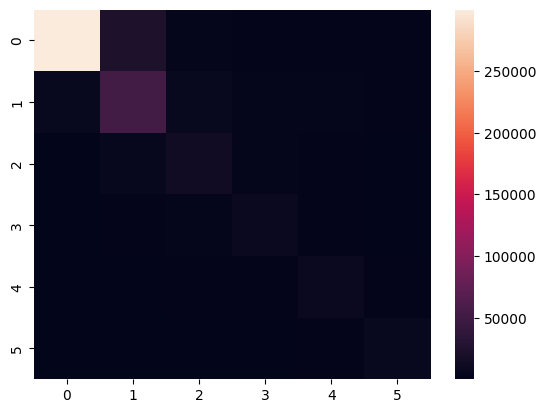

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt 

sns.heatmap(confusion_matrix(y_test, y_pred), annot=False)
plt.savefig("../results/cm_random_forest.png")